# Linear Programming with Multiplicative Weights: Metabolic Flux Feasibility
In this example, we use the multiplicative weights update algorithm (MWA) to solve a linear programming _feasibility_ problem: finding a metabolic flux distribution that respects a set of enzyme capacity limits.

> __Learning Objectives.__
>
> By the end of this example, you will be able to:
>
> * __Formulate a feasibility problem on the simplex:__ Express an enzyme-limited flux allocation as the search for a non-negative flux vector that sums to a fixed total and satisfies a set of capacity constraints.
> * __Apply the multiplicative weights algorithm to a linear program:__ Treat each reaction flux as an expert and use constraint violations to update the weights until the candidate satisfies every capacity limit.
> * __Verify and interpret the solution:__ Check that the returned flux distribution meets all enzyme limits and read the per-iteration violation to watch the algorithm converge.

Let's get started!
___

## Background: linear programming with multiplicative weights
The lecture introduced a multiplicative weights method for linear programs written as the search for a point on the simplex that satisfies a set of packing constraints.

> We look for a point $\mathbf{x}\in\Delta_{m} = \{\mathbf{x}\ge 0 : \sum_{i=1}^{m} x_{i} = \tau\}$ that satisfies $\mathbf{A}\mathbf{x}\le\mathbf{b}$. Each decision variable $x_{i}$ is treated as an _expert_ with weight $w_{i}$, and the candidate solution is $x_{i} = (\tau/\Phi)\,w_{i}$ with $\Phi = \sum_{i} w_{i}$. When a constraint $k$ is violated, every weight is updated with $w_{j}\gets w_{j}\,(1 - \eta\,a_{kj})$, shifting mass away from the variables that load the violated constraint.

The algorithm stops when the candidate satisfies all constraints within a tolerance, or when it reaches the iteration limit. We implement this in [the `solve(...)` method](src/Solve.jl) acting on [a `MyLinearProgramFeasibilityProblem` instance](src/Types.jl).
___

## The metabolic flux feasibility problem
Consider a small metabolic network with five reactions. Each reaction $i$ carries a flux $x_{i}\ge 0$, and the fluxes share a fixed total budget $\sum_{i} x_{i} = \tau$ that normalizes the overall metabolic activity. Three enzymes catalyze these reactions, and each enzyme $k$ has a limited capacity $b_{k}$. Running reaction $i$ consumes $a_{ki}$ units of enzyme $k$ per unit flux.

> __Question.__ Does a flux distribution exist that uses the full budget $\tau$ while keeping every enzyme within its capacity, $\mathbf{A}\mathbf{x}\le\mathbf{b}$? If so, find one.

We encode the enzyme usage in the matrix $\mathbf{A}\in\mathbb{R}^{3\times 5}$ and the capacities in the vector $\mathbf{b}\in\mathbb{R}^{3}$. Let's set up the calculation.
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which loads external packages and the module's local codes.

> The `include(...)` command evaluates the contents of `Include.jl` in the notebook's global scope. This file sets paths, loads required packages, and includes the local `src/` files that define [the `MyLinearProgramFeasibilityProblem` type](src/Types.jl), its [`build(...)` method](src/Factory.jl), and the [`solve(...)` method](src/Solve.jl).

Let's load our environment:

In [1]:
include("Include.jl"); # load my codes, packages, etc

### Build the feasibility problem
We collect the enzyme usage matrix $\mathbf{A}$, the capacity vector $\mathbf{b}$, and the total flux budget $\tau$, then construct [a `MyLinearProgramFeasibilityProblem` instance](src/Types.jl) with [the `build(...)` method](src/Factory.jl). We store the model in the `flux_problem` variable.

In [2]:
flux_problem = let

    # enzyme usage A[k,i]: capacity of enzyme k used per unit flux of reaction i -
    A = [
        1.0  0.0  2.0  0.0  1.0 ;  # enzyme E1
        0.0  1.0  1.0  1.0  0.0 ;  # enzyme E2
        1.0  1.0  0.0  0.0  2.0 ;  # enzyme E3
    ];
    b = [8.0, 5.0, 7.0]; # enzyme capacities
    τ = 10.0;            # total flux budget: sum(x) = τ

    # build the feasibility problem (ϵ is the constraint tolerance) -
    problem = build(MyLinearProgramFeasibilityProblem, (
        A = A,    # enzyme usage matrix (3 enzymes × 5 reactions)
        b = b,    # enzyme capacities
        τ = τ,    # total flux budget
        ϵ = 0.01, # tolerance
    ));

    problem; # return the problem
end;

The `build(...)` method fills in the learning rate $\eta$, the coefficient bound $\rho$, and the iteration limit $T$ from defaults. The default learning rate $\eta = 1/(2\rho)$ keeps every weight update non-negative. Let's confirm the parameters the solver will use:

In [3]:
(η = flux_problem.η, ρ = flux_problem.ρ, T = flux_problem.T, ϵ = flux_problem.ϵ)

(η = 0.25, ρ = 2.0, T = 16095, ϵ = 0.01)

### Solve the feasibility problem
We pass the `flux_problem` to [the `solve(...)` method](src/Solve.jl). It runs the multiplicative weights iteration and returns a dictionary holding the candidate solution `x`, a `feasible` flag, the iteration count, and the per-iteration constraint violation. We store the dictionary in `flux_result`.

In [4]:
flux_result = solve(flux_problem);

Did the algorithm find a feasible flux distribution, and how many iterations did it take?

In [5]:
(feasible = flux_result["feasible"], iterations = flux_result["iterations"])

(feasible = true, iterations = 12)

### The flux distribution
Let's look at the flux assigned to each reaction. `Unhide` the code block below to see how we build the table [with the `pretty_table(...)` method](https://github.com/ronisbr/PrettyTables.jl). The fluxes are non-negative and sum to the budget $\tau$.

In [6]:
let
    x = flux_result["x"];
    df = DataFrame();
    for i ∈ eachindex(x)
        push!(df, (reaction = "R$(i)", flux = x[i]));
    end
    push!(df, (reaction = "total", flux = sum(x)));

    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

 ---------- ----------
  reaction       flux 
    String    Float64 
 ---------- ----------
        R1    4.45005
        R2   0.792013
        R3   0.834384
        R4    3.33754
        R5   0.586015
     total       10.0
 ---------- ----------


### Check the enzyme capacity limits
A flux distribution is viable only if it respects every enzyme capacity. Let's compare the enzyme usage $\mathbf{A}\mathbf{x}$ against the capacities $\mathbf{b}$ and confirm that no limit is exceeded within the tolerance. The `slack` column is the unused capacity $b_{k} - (\mathbf{A}\mathbf{x})_{k}$.

In [7]:
let
    A = flux_problem.A;
    b = flux_problem.b;
    x = flux_result["x"];
    ϵ = flux_problem.ϵ;
    usage = A*x;

    df = DataFrame();
    for k ∈ eachindex(b)
        push!(df, (enzyme = "E$(k)", usage = usage[k], capacity = b[k], slack = b[k] - usage[k]));
    end
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    @assert all(usage .<= b .+ 2*ϵ) # every enzyme within capacity (within tolerance)
end

 -------- --------- ---------- -----------
  enzyme     usage   capacity       slack 
  String   Float64    Float64     Float64 
 -------- --------- ---------- -----------
      E1   6.70483        8.0     1.29517
      E2   4.96394        5.0   0.0360648
      E3   6.41409        7.0    0.585907
 -------- --------- ---------- -----------


### Watching the algorithm converge
The solver records the worst constraint violation $\max_{k}\,\{(\mathbf{A}\mathbf{x})_{k} - b_{k}\}$ at each iteration. A positive value means at least one enzyme limit is exceeded; once the curve reaches zero or below, the candidate flux distribution is feasible. Let's plot the violation against the iteration count.

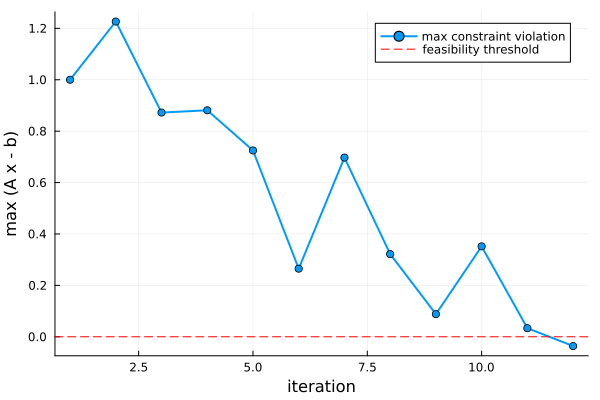

In [8]:
let
    violation = flux_result["violation"];

    plot(1:length(violation), violation,
        lw = 2, marker = :circle, label = "max constraint violation",
        xlabel = "iteration", ylabel = "max (A x - b)", legend = :topright);
    hline!([0.0], ls = :dash, lw = 1, color = :red, label = "feasibility threshold");
end

## Summary
In this example, we used the multiplicative weights update algorithm to solve a linear programming feasibility problem, finding a metabolic flux distribution that uses a fixed total budget while respecting every enzyme capacity limit.

> __Key Takeaways:__
>
> * __Feasibility on the simplex:__ Treating each reaction flux as an expert, the algorithm searches the simplex for a non-negative flux vector that sums to the budget and satisfies all capacity constraints.
> * __Violations drive the updates:__ Each exceeded capacity down-weights the reactions responsible, so the candidate solution moves toward feasibility over successive iterations.
> * __Convergence is observable:__ The worst constraint violation decreases to zero, giving a direct signal that the returned flux distribution is viable.

The multiplicative weights algorithm turns a linear feasibility question into a short sequence of weight updates that returns a flux distribution satisfying every enzyme limit. This same feasibility engine is the building block for the optimization problems in the activities that follow.
___